In [3]:
import pandas as pd

df = pd.read_excel('/content/Online Retail.xlsx')

print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())

print("\nFirst 5 Rows:")
display(df.head())

Dataset Shape: (541909, 8)

Column Names:
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']

First 5 Rows:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [2]:
print("Data Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Data Types:
InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID            float64
Country                object
dtype: object

Missing Values:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

Duplicate Rows:
5268


In [4]:
cleaned_df = df.copy()
print("Original rows:", len(cleaned_df))
cleaned_df = cleaned_df.drop_duplicates()
print("After removing duplicates:", len(cleaned_df))
cleaned_df = cleaned_df.dropna(subset=['Description'])
print("After removing missing Description:", len(cleaned_df))
cleaned_df = cleaned_df.dropna(subset=['CustomerID'])
print("After removing missing CustomerID:", len(cleaned_df))
cleaned_df = cleaned_df[cleaned_df['Quantity'] > 0]
print("After removing invalid Quantity:", len(cleaned_df))
cleaned_df = cleaned_df[cleaned_df['UnitPrice'] > 0]
print("After removing invalid UnitPrice:", len(cleaned_df))
cleaned_df['CustomerID'] = cleaned_df['CustomerID'].astype(int)
cleaned_df['TotalSales'] = cleaned_df['Quantity'] * cleaned_df['UnitPrice']
print("\nFinal Dataset Shape:", cleaned_df.shape)
print("\nRemaining Missing Values:")
print(cleaned_df.isnull().sum())
print("\nRemaining Duplicate Rows:", cleaned_df.duplicated().sum())
display(cleaned_df.head())

Original rows: 541909
After removing duplicates: 536641
After removing missing Description: 535187
After removing missing CustomerID: 401604
After removing invalid Quantity: 392732
After removing invalid UnitPrice: 392692

Final Dataset Shape: (392692, 9)

Remaining Missing Values:
InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
TotalSales     0
dtype: int64

Remaining Duplicate Rows: 0


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalSales
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


In [5]:
# Save cleaned dataset
cleaned_df.to_csv('/content/cleaned_online_retail.csv', index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [6]:
# Descriptive statistics
print("Descriptive Statistics:")
display(cleaned_df.describe())

Descriptive Statistics:


,Quantity,InvoiceDate,UnitPrice,CustomerID,TotalSales
count,392692.000000,392692,392692.000000,392692.000000,392692.000000
mean,13.119702,2011-07-10 19:13:07.771892480,3.125914,15287.843865,22.631500
min,1.000000,2010-12-01 08:26:00,0.001000,12346.000000,0.001000
25%,2.000000,2011-04-07 11:12:00,1.250000,13955.000000,4.950000
50%,6.000000,2011-07-31 12:02:00,1.950000,15150.000000,12.450000
75%,12.000000,2011-10-20 12:53:00,3.750000,16791.000000,19.800000
max,80995.000000,2011-12-09 12:50:00,8142.750000,18287.000000,168469.600000
std,180.492832,NaN,22.241836,1713.539549,311.099224


In [13]:
# Overall sales summary
total_sales = cleaned_df['TotalSales'].sum()
total_orders = cleaned_df['InvoiceNo'].nunique()
total_customers = cleaned_df['CustomerID'].nunique()
average_order_value = total_sales / total_orders

print("Total Sales:", round(total_sales, 2))
print("Total Orders:", total_orders)
print("Total Customers:", total_customers)
print("Average Order Value:", round(average_order_value, 2))

Total Sales: 8887208.89
Total Orders: 18532
Total Customers: 4338
Average Order Value: 479.56


In [8]:
# Sales by country
country_sales = (
    cleaned_df.groupby('Country')['TotalSales']
    .sum()
    .sort_values(ascending=False)
)

display(country_sales.head(10))

,TotalSales
Country,
United Kingdom,7285024.644
Netherlands,285446.340
EIRE,265262.460
Germany,228678.400
France,208934.310
Australia,138453.810
Spain,61558.560
Switzerland,56443.950
Belgium,41196.340


In [9]:
# Top 10 products by sales
product_sales = (
    cleaned_df.groupby('Description')['TotalSales']
    .sum()
    .sort_values(ascending=False)
)

display(product_sales.head(10))

,TotalSales
Description,
"PAPER CRAFT , LITTLE BIRDIE",168469.60
REGENCY CAKESTAND 3 TIER,142264.75
WHITE HANGING HEART T-LIGHT HOLDER,100392.10
JUMBO BAG RED RETROSPOT,85040.54
MEDIUM CERAMIC TOP STORAGE JAR,81416.73
POSTAGE,77803.96
PARTY BUNTING,68785.23
ASSORTED COLOUR BIRD ORNAMENT,56413.03
Manual,53419.93


In [10]:
# Create Month column
cleaned_df['Month'] = cleaned_df['InvoiceDate'].dt.to_period('M').astype(str)

monthly_sales = (
    cleaned_df.groupby('Month')['TotalSales']
    .sum()
    .sort_index()
)

display(monthly_sales)

,TotalSales
Month,
2010-12,570422.730
2011-01,568101.310
2011-02,446084.920
2011-03,594081.760
2011-04,468374.331
2011-05,677355.150
2011-06,660046.050
2011-07,598962.901
2011-08,644051.040


In [11]:
# Correlation analysis
correlation = cleaned_df[['Quantity', 'UnitPrice', 'TotalSales']].corr()

print("Correlation Matrix:")
display(correlation)

Correlation Matrix:


,Quantity,UnitPrice,TotalSales
Quantity,1.000000,-0.004578,0.914451
UnitPrice,-0.004578,1.000000,0.081619
TotalSales,0.914451,0.081619,1.000000


In [12]:
# Outlier detection using IQR

def check_outliers(column):
    Q1 = cleaned_df[column].quantile(0.25)
    Q3 = cleaned_df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = cleaned_df[
        (cleaned_df[column] < lower) |
        (cleaned_df[column] > upper)
    ]

    print(column)
    print("Lower Bound:", lower)
    print("Upper Bound:", upper)
    print("Number of Outliers:", len(outliers))
    print()

check_outliers('Quantity')
check_outliers('UnitPrice')
check_outliers('TotalSales')

Quantity
Lower Bound: -13.0
Upper Bound: 27.0
Number of Outliers: 25616

UnitPrice
Lower Bound: -2.5
Upper Bound: 7.5
Number of Outliers: 34112

TotalSales
Lower Bound: -17.325
Upper Bound: 42.074999999999996
Number of Outliers: 31231



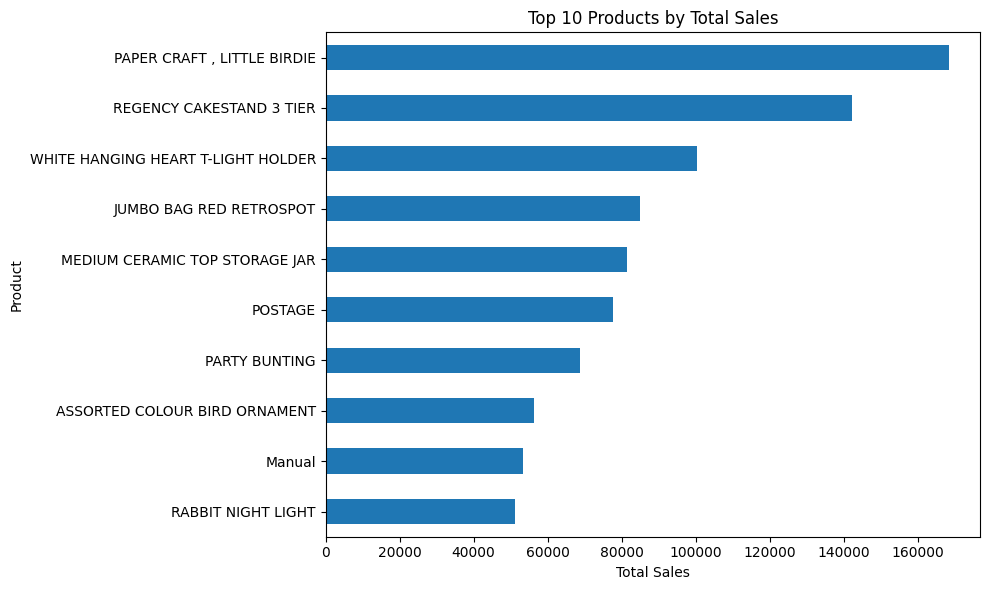

<Figure size 640x480 with 0 Axes>

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

category_sales = (
    cleaned_df.groupby('Description')['TotalSales']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

category_sales.sort_values().plot(kind='barh')

plt.title('Top 10 Products by Total Sales')
plt.xlabel('Total Sales')
plt.ylabel('Product')
plt.tight_layout()
plt.show()
plt.savefig('/content/top_10_products.png', dpi=300)

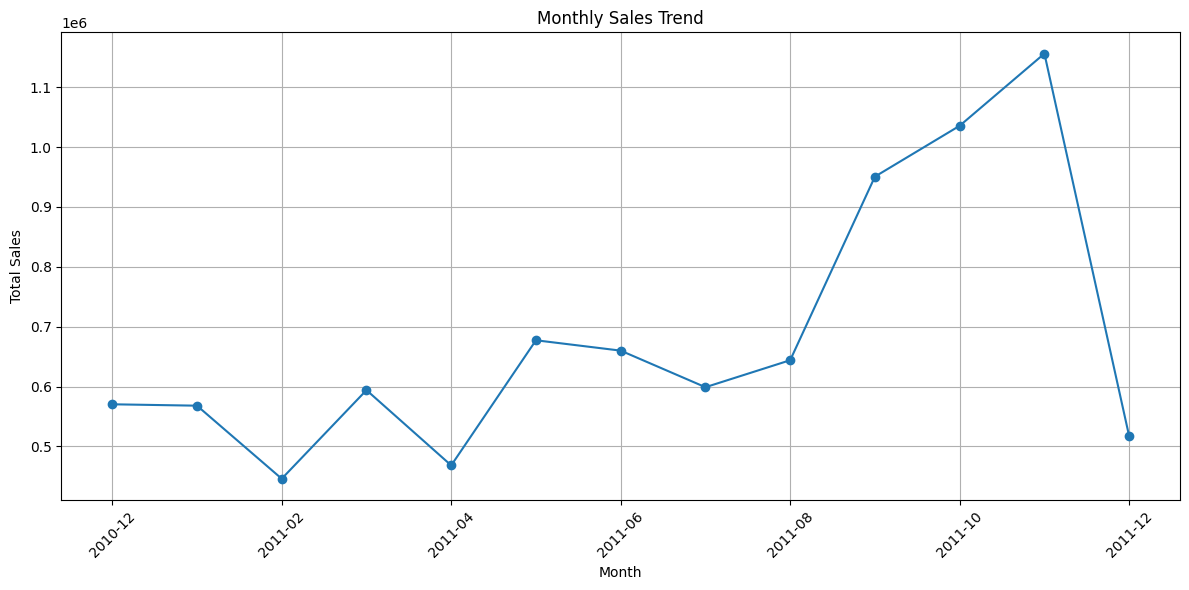

<Figure size 640x480 with 0 Axes>

In [20]:
plt.figure(figsize=(12, 6))

monthly_sales = (
    cleaned_df.groupby('Month')['TotalSales']
    .sum()
    .sort_index()
)

monthly_sales.plot(kind='line', marker='o')

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()
plt.savefig('/content/monthly_sales_trend.png', dpi=300)

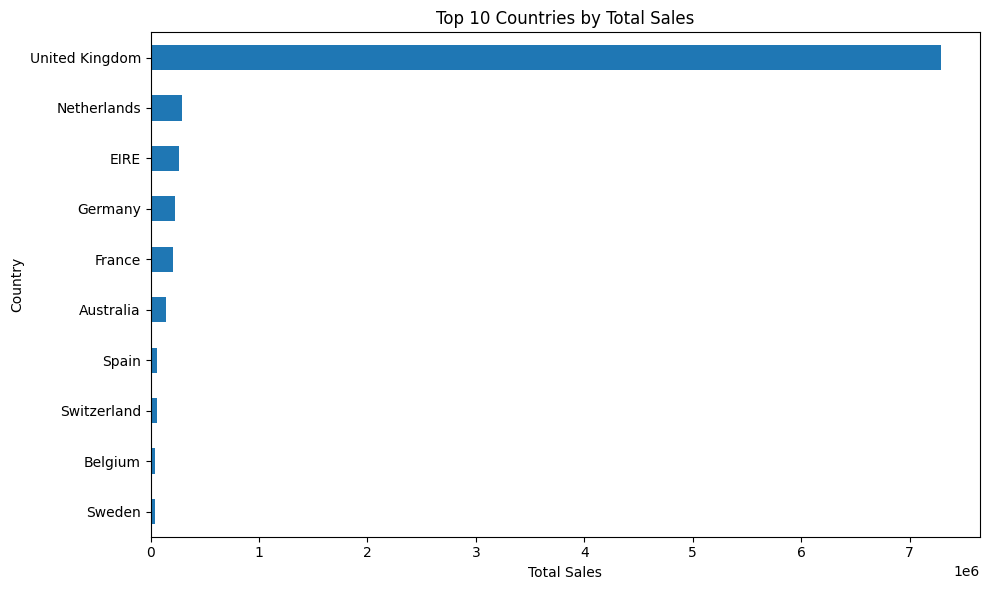

<Figure size 640x480 with 0 Axes>

In [21]:
plt.figure(figsize=(10, 6))

country_sales = (
    cleaned_df.groupby('Country')['TotalSales']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

country_sales.sort_values().plot(kind='barh')

plt.title('Top 10 Countries by Total Sales')
plt.xlabel('Total Sales')
plt.ylabel('Country')
plt.tight_layout()
plt.show()
plt.savefig('/content/top_10_countries.png', dpi=300)

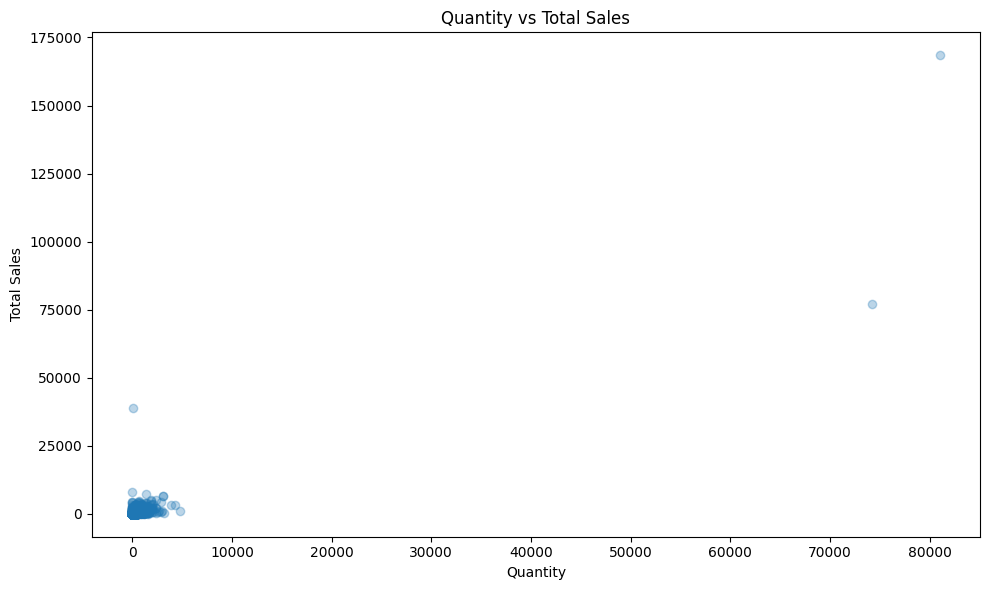

<Figure size 640x480 with 0 Axes>

In [22]:
plt.figure(figsize=(10, 6))

plt.scatter(
    cleaned_df['Quantity'],
    cleaned_df['TotalSales'],
    alpha=0.3
)

plt.title('Quantity vs Total Sales')
plt.xlabel('Quantity')
plt.ylabel('Total Sales')
plt.tight_layout()
plt.show()
plt.savefig('/content/quantity_vs_sales.png', dpi=300)

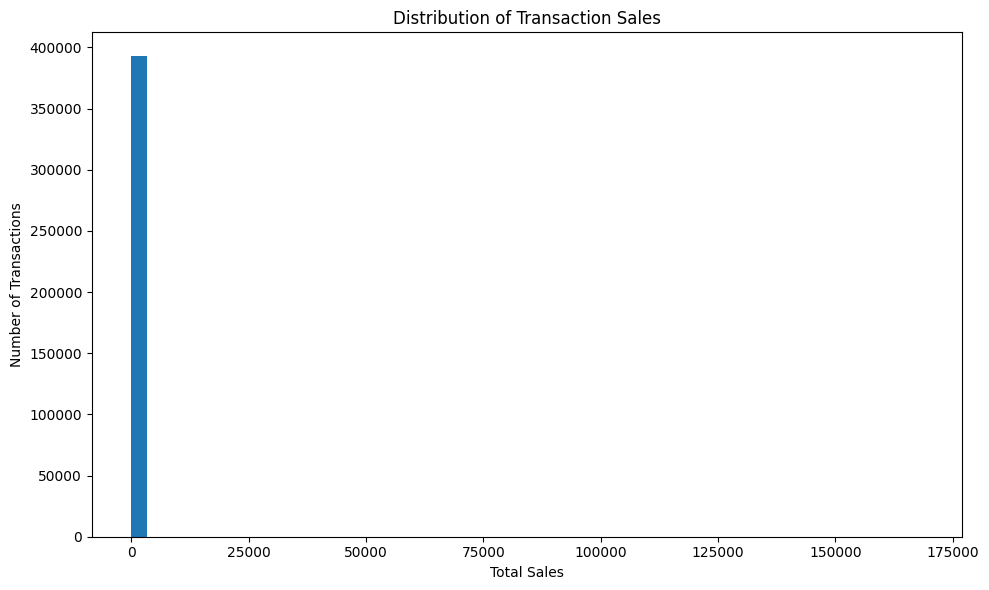

<Figure size 640x480 with 0 Axes>

In [25]:
plt.figure(figsize=(10, 6))

plt.hist(
    cleaned_df['TotalSales'],
    bins=50
)

plt.title('Distribution of Transaction Sales')
plt.xlabel('Total Sales')
plt.ylabel('Number of Transactions')
plt.tight_layout()
plt.show()
plt.savefig('/content/sales_distribution.png', dpi=300)